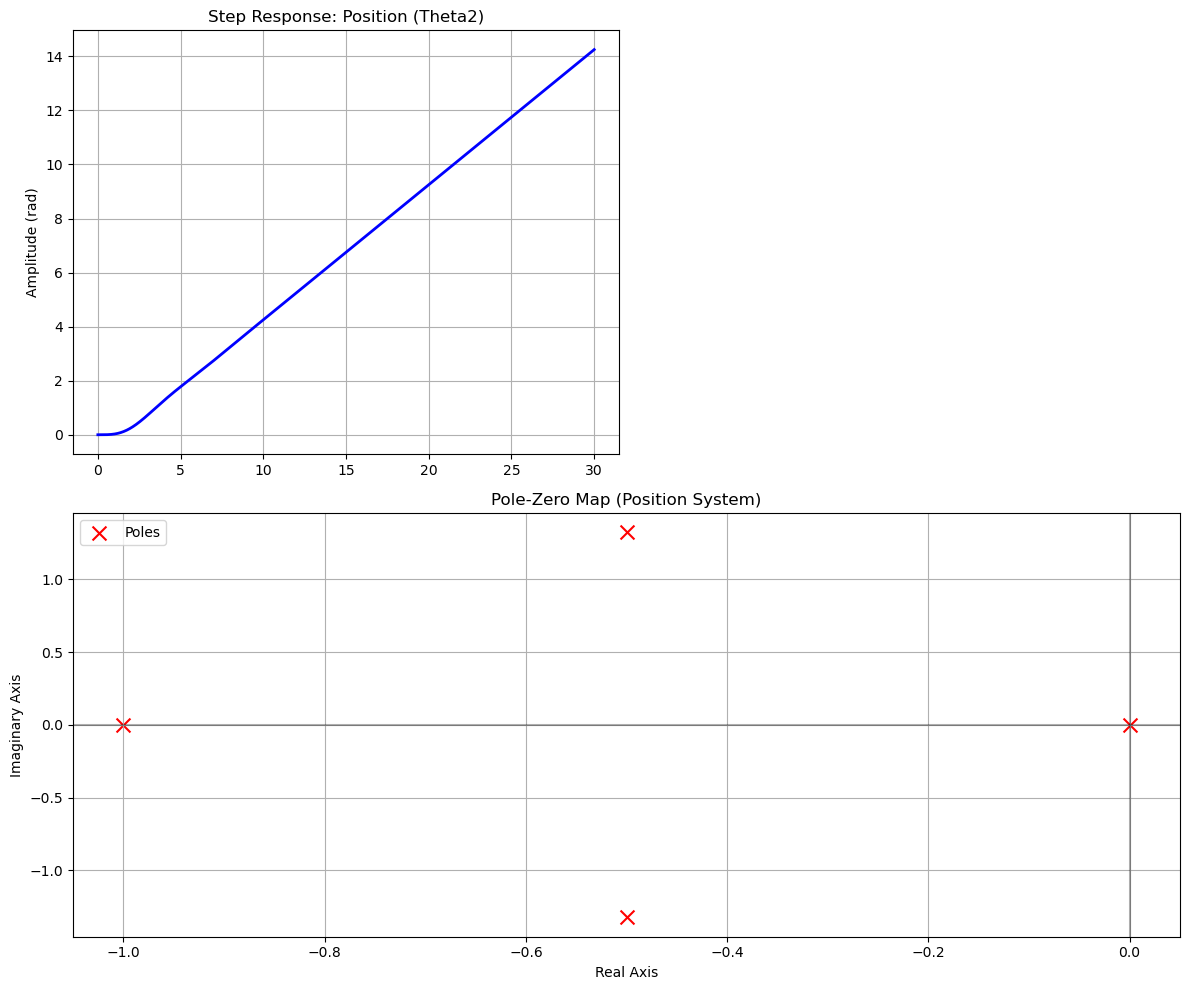

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# System Parameters
J1, J2, B1, B2, K = 1, 1, 1, 1, 1

# Numerator and Denominator setup
# Velocity TF: Omega2(s)/T(s)
num_vel = [K]
den_vel = [J1*J2, (B1*J2 + B2*J1), (J1*K + J2*K + B1*B2), (B1*K + B2*K)]
sys_vel = signal.TransferFunction(num_vel, den_vel)

# Position TF: Theta2(s)/T(s)
num_pos = [K]
den_pos = den_vel + [0]
sys_pos = signal.TransferFunction(num_pos, den_pos)

# Simulation time
t = np.linspace(0, 30, 1000)
t_p, y_p = signal.step(sys_pos, T=t)
t_v, y_v = signal.step(sys_vel, T=t)

# Plotting
fig = plt.figure(figsize=(12, 10))

# Position Step Response
plt.subplot(2, 2, 1)
plt.plot(t_p, y_p, 'b', lw=2)
plt.title('Step Response: Position (Theta2)')
plt.ylabel('Amplitude (rad)')
plt.grid(True)


# Pole-Zero Map
poles = sys_pos.poles
plt.subplot(2, 1, 2)
plt.scatter(np.real(poles), np.imag(poles), marker='x', s=100, color='red', label='Poles')
plt.axhline(0, color='black', alpha=0.3)
plt.axvline(0, color='black', alpha=0.3)
plt.title('Pole-Zero Map (Position System)')
plt.xlabel('Real Axis')
plt.ylabel('Imaginary Axis')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()